In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import LabelBinarizer , MinMaxScaler
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay , make_scorer , hinge_loss
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [51]:
X , y = fetch_openml('mnist_784' , version=1 , return_X_y=True)
X = X.to_numpy()
y = y.to_numpy()
X = MinMaxScaler().fit_transform(X)
x_train, x_test, y_train, y_test = X[:60000 ], X[ 60000 : ] , y[ : 60000 ] , y[ 60000 : ]

In [80]:
y_train_0 = -1*(np.ones(len(y_train)))
y_test_0 = -1*(np.ones(len(y_test)))

index_0 = np.where(y_train=='0')
y_train_0[index_0] = 1

index_0 = np.where(y_test=='0')
y_test_0[index_0] = 1

In [52]:
clf = Perceptron(random_state=1729)

In [53]:
y_train_ovr = LabelBinarizer().fit_transform(y_train)
for i in range(10):
    print(f"{y_train[i]}:{y_train_ovr[i]}")

5:[0 0 0 0 0 1 0 0 0 0]
0:[1 0 0 0 0 0 0 0 0 0]
4:[0 0 0 0 1 0 0 0 0 0]
1:[0 1 0 0 0 0 0 0 0 0]
9:[0 0 0 0 0 0 0 0 0 1]
2:[0 0 1 0 0 0 0 0 0 0]
1:[0 1 0 0 0 0 0 0 0 0]
3:[0 0 0 1 0 0 0 0 0 0]
1:[0 1 0 0 0 0 0 0 0 0]
4:[0 0 0 0 1 0 0 0 0 0]


In [54]:
clf.fit(x_train , y_train)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",1729


In [55]:
print(f"Shape of weight matrix:{clf.coef_.shape} , Bias vector:{clf.intercept_}")

Shape of weight matrix:(10, 784) , Bias vector:[ -94.  -13.  -46.  -77.  -33.   23.  -85.   -6. -172.  -88.]


In [56]:
scores = clf.decision_function(x_train[6].reshape(1,-1))
print(f"scores : {scores}")
print(f"The Predicted scores : {np.argmax(scores)}")

scores : [[-631.88492118  154.366213    -65.23234141  -90.95338716 -189.29568627
  -137.14385236  -99.64604383 -159.09859285 -136.86391388 -199.26120723]]
The Predicted scores : 1


In [57]:
print("Predicted Output\n")
print(clf.predict(x_train[0].reshape(1,-1)))

Predicted Output

['5']


In [58]:
y_hat = clf.predict(x_train)
print(classification_report(y_train , y_hat))

              precision    recall  f1-score   support

           0       0.98      0.95      0.97      5923
           1       0.94      0.98      0.96      6742
           2       0.89      0.90      0.90      5958
           3       0.86      0.87      0.87      6131
           4       0.89      0.94      0.91      5842
           5       0.81      0.88      0.85      5421
           6       0.92      0.97      0.94      5918
           7       0.91      0.94      0.92      6265
           8       0.92      0.77      0.84      5851
           9       0.92      0.82      0.87      5949

    accuracy                           0.90     60000
   macro avg       0.90      0.90      0.90     60000
weighted avg       0.91      0.90      0.90     60000



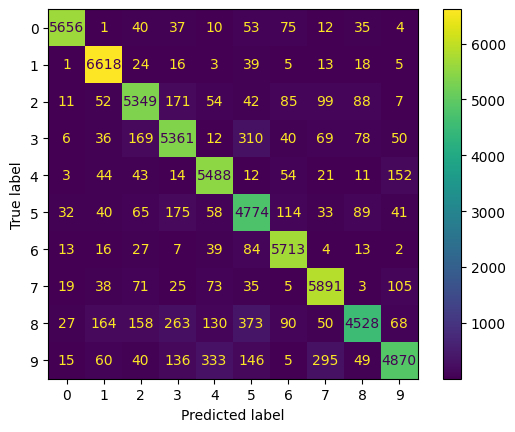

In [59]:
cm_matrix = ConfusionMatrixDisplay.from_predictions(y_train , y_hat , values_format=".5g")

#### Making a Pipeline

In [60]:
perceptron_model = Pipeline([
    ("min_max_scaler" , MinMaxScaler()),
    ("perceptron" , Perceptron())
])
perceptron_model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('min_max_scaler', ...), ('perceptron', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True


#### GridSearchCV

In [82]:
scoring = make_scorer(hinge_loss, greater_is_better=False)
lr_grid = [1/2 ** n for n in range(1,6)]
bin_clf_gscv = GridSearchCV(Perceptron(),param_grid={"eta0":lr_grid}, scoring=scoring,cv=5)
bin_clf_gscv.fit(x_train,y_train_0)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Perceptron()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'eta0': [0.5, 0.25, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(h...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidat

In [84]:
bin_clf_gscv.cv_results_

{'mean_fit_time': array([0.71948829, 0.72710247, 0.67146597, 0.54486718, 1.4504231 ]),
 'std_fit_time': array([0.16305391, 0.15928138, 0.13045038, 0.06476979, 0.82027783]),
 'mean_score_time': array([0.0118494 , 0.0117065 , 0.0107996 , 0.01018844, 0.03058286]),
 'std_score_time': array([0.00093192, 0.00061466, 0.0011649 , 0.00133427, 0.01568757]),
 'param_eta0': masked_array(data=[0.5, 0.25, 0.125, 0.0625, 0.03125],
              mask=[False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'eta0': 0.5},
  {'eta0': 0.25},
  {'eta0': 0.125},
  {'eta0': 0.0625},
  {'eta0': 0.03125}],
 'split0_test_score': array([-0.02166667, -0.02166667, -0.02166667, -0.02166667, -0.02166667]),
 'split1_test_score': array([-0.0395, -0.0395, -0.0395, -0.0395, -0.0395]),
 'split2_test_score': array([-0.02816667, -0.02816667, -0.02816667, -0.02816667, -0.02816667]),
 'split3_test_score': array([-0.023     , -0.023     , -0.023     , -0.04416667, -0.04416667]),
 'split4_test_score': array

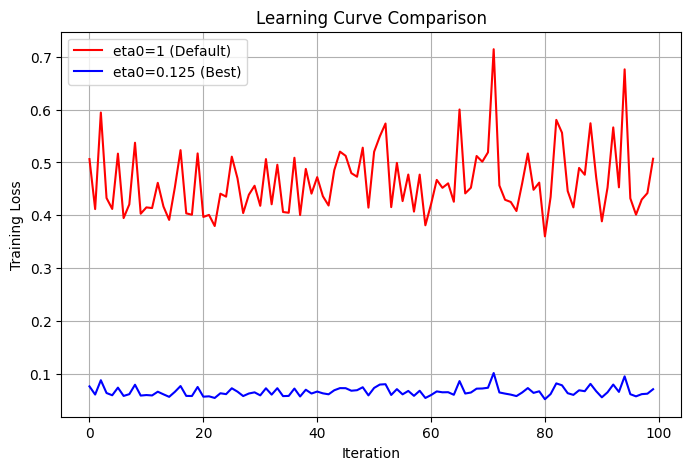

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.metrics import hinge_loss

iterations = 100

# 1. Pehla Model: Normal Speed (eta0=1 by default)
bin_clf1 = Perceptron(max_iter=1000, random_state=2094, eta0=1)
Loss_clf1 = [] # Ise hum yahan wapas banayenge

for i in range(iterations):
    bin_clf1.partial_fit(x_train, y_train_0, classes=np.array([1, -1]))
    y_hat_1 = bin_clf1.decision_function(x_train)
    Loss_clf1.append(hinge_loss(y_train_0, y_hat_1))


# 2. Doosra Model: Best Speed (eta0=0.125)
best_bin_clf = Perceptron(max_iter=1000, random_state=2094, eta0=0.125)
Loss = []

for i in range(iterations):
    best_bin_clf.partial_fit(x_train, y_train_0, classes=np.array([1, -1]))
    y_hat_2 = best_bin_clf.decision_function(x_train)
    Loss.append(hinge_loss(y_train_0, y_hat_2))


# 3. Dono ka result Graph par plot karna
plt.figure(figsize=(8, 5))
plt.plot(np.arange(iterations), Loss_clf1, label='eta0=1 (Default)', color='red')
plt.plot(np.arange(iterations), Loss, label='eta0=0.125 (Best)', color='blue')

plt.grid(True)
plt.legend()
plt.title("Learning Curve Comparison")
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.show()